<a href="https://colab.research.google.com/github/IhtishamHaq/EnKF_analysis/blob/master/LHS_PRCC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latin Hypercube Sampling & Partial Rank Correlation Coefficients  <br/> *~ a method for analyzing model sensitivity to parameters ~*

#### Importing packages that will be used.

In [1]:
import numpy as np

from scipy import special

import random

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display

import pandas as pd

import matplotlib.pyplot as plt


### Specify the number of parameters to sample and the number of samples to draw from each parameter distribution.
#### *Do not include any parameters that should be left fixed in parameterCount - those will be specified later. When choosing number of samples to draw, note that more samples (~ 1000) yields better results while fewer (~50) is faster for testing, since it requires fewer model solves.*

In [2]:
# Number of parameters to sample
parameterCount = 8;

# Number of samples to draw for each parameter
sampleCount = 100;

#### This defines functions for specifying sampled parameters' names and distributions  as well as drawing samples from a user-specified parameter distribution. Does not need any user edits.

In [3]:
def parNameDist(Name,Distribution):
    paramTemp = {}
    paramTemp['Name']=Name
    paramTemp['Dist']=Distribution

    return paramTemp

def sampleDistrib(modelParamName,distrib,distribSpecs):

    if distrib == 'uniform':

        mmin = distribSpecs[0].value
        mmax = distribSpecs[1].value

        intervalwidth = (mmax - mmin) / sampleCount      # width of each
                                                         # sampling interval
        samples = []

        for sample in range(sampleCount):

            lower = mmin + intervalwidth * (sample-1)    # lb of interval
            upper = mmin + intervalwidth * (sample)      # ub of interval

            sampleVal = np.random.uniform(lower, upper)  # draw a random sample
                                                         # within the interval
            samples.append(sampleVal)



    elif distrib == 'normal':

        mmean= distribSpecs[0].value
        mvar = distribSpecs[1].value

        lower = np.sqrt(2*mvar)*special.erfinv(-0.9999)+mmean # set lb of 1st
                                                              # sample interval
        samples = []

        for sample in range(sampleCount):

            n = sample + 1

            if n != sampleCount:
                upper = (np.sqrt(2*mvar)*special.erfinv(2*n/sampleCount-1)
                         + mmean)                        # ub of sample interval
            else:
                upper = np.sqrt(2*mvar)*special.erfinv(0.9999) + mmean

            sampleVal = np.random.uniform(lower, upper)  # draw a random sample
                                                         # within the interval

            samples.append(sampleVal)

            lower = upper           # set current ub as the lb for next interval



    elif distrib == 'triangle':

        mmin = distribSpecs[0].value
        mmax = distribSpecs[1].value
        mmode= distribSpecs[2].value

        samples = []

        for sample in range(sampleCount):

            n = sample + 1

            intervalarea = 1/sampleCount

            ylower = intervalarea*(n-1) # use cdf to read off area as y's &
            yupper = intervalarea*(n)   # get corresponding x's for the pdf


            # Check to see if y values = cdf(x <= mmode)
            # for calculating correxponding x values:

            if ylower <= ((mmode - mmin)/(mmax - mmin)):
                lower = np.sqrt(ylower*(mmax - mmin)*(mmode - mmin)) + mmin

            else:
                lower = mmax-np.sqrt((1 - ylower)*(mmax - mmin)*(mmax - mmode))


            if yupper <= ((mmode - mmin)/(mmax - mmin)):
                upper = np.sqrt(yupper*(mmax - mmin)*(mmode - mmin)) + mmin;

            else:
                upper = mmax-np.sqrt((1 - yupper)*(mmax - mmin)*(mmax - mmode))


            sampleVal = np.random.uniform(lower, upper)

            samples.append(sampleVal)


    b = int(np.ceil(sampleCount/10))
    plt.hist(samples, density = 1, bins = b)

    B=str(b)

    plt.title('Histogram of ' + modelParamName
              + ' parameter samples for ' + B + ' bins')

    plt.ylabel('proportion of samples');
    plt.xlabel(modelParamName + ' value')

    plt.show()

    return samples

#### Calls the function to ask for user input to name parameters and specify distributions.
### Type these in text input boxes and dropdowns that will appear below after running the cell.

In [5]:
params = {}

for i in range(parameterCount):

    s=str(i)

    params[i] = interactive(parNameDist,
                            Name='Type parameter ' + s + ' name',
                            Distribution=['uniform','normal','triangle'])

    display(params[i])

interactive(children=(Text(value='Type parameter 0 name', description='Name'), Dropdown(description='Distribut…

interactive(children=(Text(value='Type parameter 1 name', description='Name'), Dropdown(description='Distribut…

interactive(children=(Text(value='Type parameter 2 name', description='Name'), Dropdown(description='Distribut…

interactive(children=(Text(value='Type parameter 3 name', description='Name'), Dropdown(description='Distribut…

interactive(children=(Text(value='Type parameter 4 name', description='Name'), Dropdown(description='Distribut…

interactive(children=(Text(value='Type parameter 5 name', description='Name'), Dropdown(description='Distribut…

interactive(children=(Text(value='Type parameter 6 name', description='Name'), Dropdown(description='Distribut…

interactive(children=(Text(value='Type parameter 7 name', description='Name'), Dropdown(description='Distribut…

### Input parameter distribution specifics in the interactive boxes that appear below after running this cell.

In [18]:
distribSpecs={}

for i in range(parameterCount):

    parName = params[i].result['Name']

    print('Enter distribution specifics for parameter ' + parName + ':')

    if params[i].result['Dist'] == 'normal':

        distribSpecs[parName] = {}

        distribSpecs[parName][0] = widgets.FloatText(
                value=2,
                description='Mean:'
              )
        distribSpecs[parName][1] = widgets.FloatText(
                value=1,
                description='Variance:'
              )

        display(distribSpecs[parName][0], distribSpecs[parName][1])

    elif params[i].result['Dist'] == 'uniform':

        distribSpecs[parName] = {}

        distribSpecs[parName][0] = widgets.FloatText(
                value=0,
                description='Minimum:'
              )
        distribSpecs[parName][1] = widgets.FloatText(
                value=2,
                description='Maximum:'
              )

        display(distribSpecs[parName][0], distribSpecs[parName][1])


    elif params[i].result['Dist'] == 'triangle':

        distribSpecs[parName] = {}

        distribSpecs[parName][0] = widgets.FloatText(
                value=0,
                description='Minimum:'
              )
        distribSpecs[parName][1] = widgets.FloatText(
                value=2,
                description='Maximum:'
              )
        distribSpecs[parName][2] = widgets.FloatText(
                value=1,
                description='Mode:'
              )

        display(distribSpecs[parName][0], distribSpecs[parName][1], distribSpecs[parName][2])

Enter distribution specifics for parameter Lambda_m:


FloatText(value=2.0, description='Mean:')

FloatText(value=1.0, description='Variance:')

Enter distribution specifics for parameter  BETA_M:


FloatText(value=2.0, description='Mean:')

...

FloatText(value=2.0, description='Mean:')

FloatText(value=1.0, description='Variance:')

Enter distribution specifics for parameter DELTA_CONST:


FloatText(value=2.0, description='Mean:')

FloatText(value=1.0, description='Variance:')

#### This passes the distributions to the code for generating parameter samples, and histogram plots of samples for each parameter will appear below.

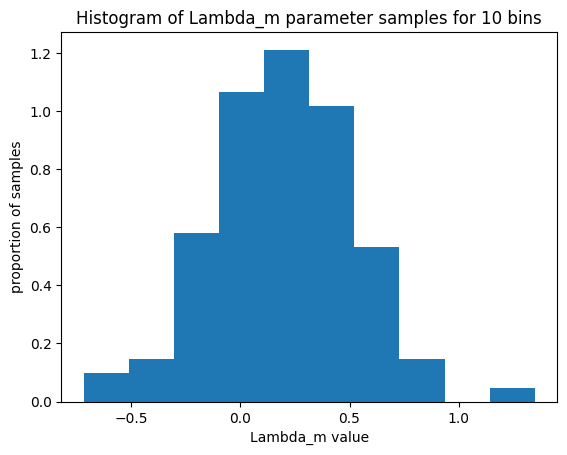

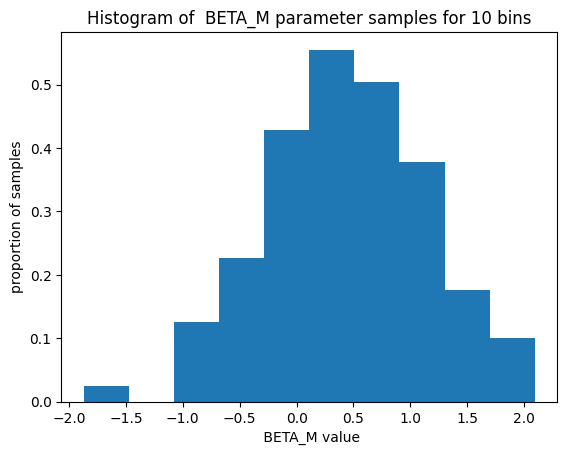

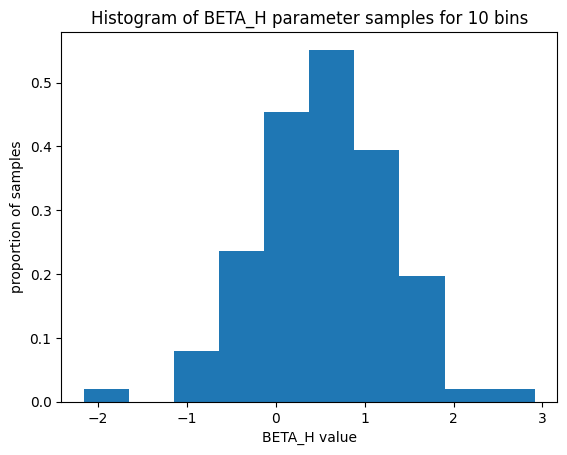

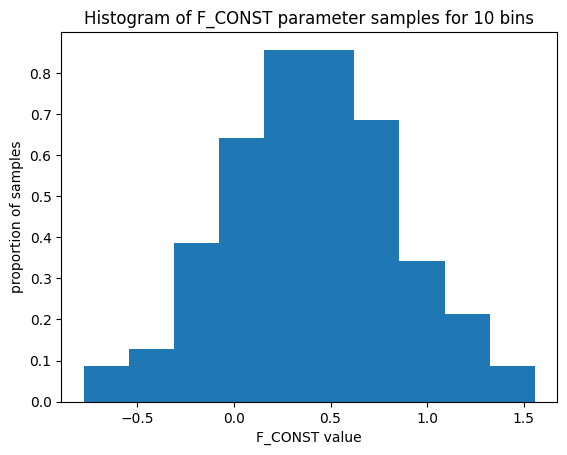

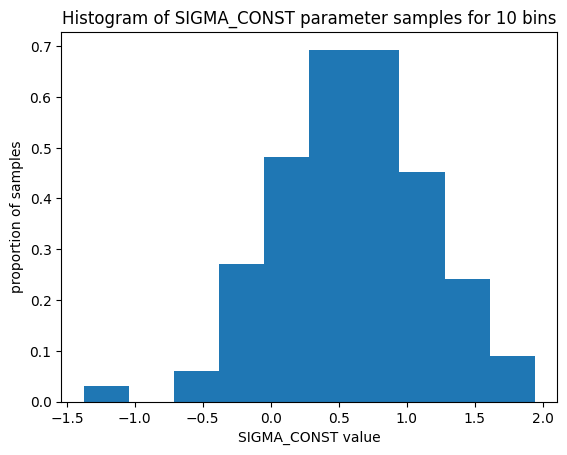

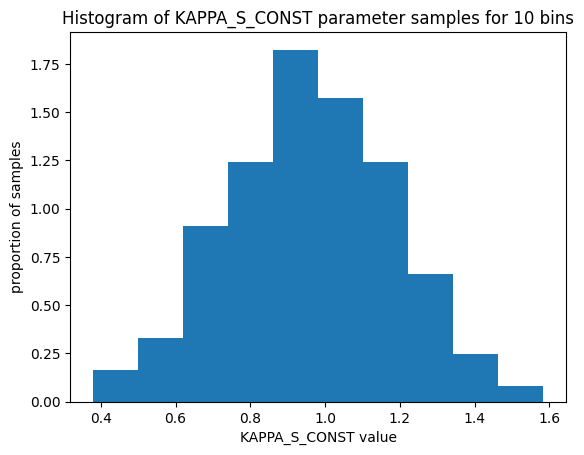

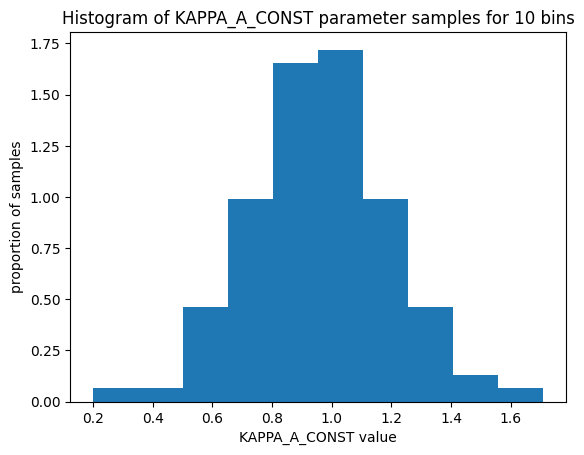

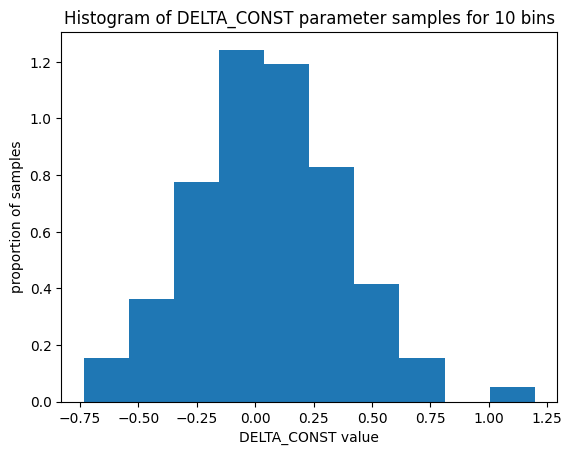

In [19]:
parameters = {}
for j in range(parameterCount):

    parameters[params[j].result['Name']] = sampleDistrib(params[j].result['Name'],
                                                         params[j].result['Dist'],
                                                         distribSpecs[params[j].result['Name']])

#### Randomly permute each set of parameter samples in order to randomly pair the samples to more fully sample the parameter space for the Monte Carlo simulations.

In [20]:
LHSparams=[]

for p in parameters:

    temp = parameters[p]
    random.shuffle(temp)

    LHSparams.append(temp)

### Define your model function.
#### Two examples have been provided below: (1) a linear function with two sampled parameters: slope and intercept, and (2) a Lotka-Volterra predator - prey model.

Note that the order and number of the parameters needs to match the order  and number of parameters speficied above to ensure accuracy when the model is solved below.

In [21]:
def testRtotal(x, sampledParams, unsampledParams):
    """
    x: array-like (you can pass np.array([t0]) or np.linspace(...) but output will be constant if nothing depends on t)
    sampledParams (length 8):
      [0] Lambda_m
      [1] BETA_M
      [2] BETA_H
      [3] F_CONST
      [4] SIGMA_CONST
      [5] KAPPA_S_CONST
      [6] KAPPA_A_CONST
      [7] DELTA_CONST

    unsampledParams: dict with fixed constants:
      - MU_H_CONST (scalar, used for all groups)
      - H_CONST    (scalar, used for all groups)
      - n          (integration grid)
    """

    Lambda_m      = float(sampledParams[0])
    BETA_M        = float(sampledParams[1])
    BETA_H        = float(sampledParams[2])
    F_CONST       = float(sampledParams[3])
    SIGMA_CONST   = float(sampledParams[4])
    KAPPA_S_CONST = float(sampledParams[5])
    KAPPA_A_CONST = float(sampledParams[6])
    DELTA_CONST   = float(sampledParams[7])

    MU_H_CONST = float(unsampledParams["MU_H_CONST"])
    H_CONST    = float(unsampledParams["H_CONST"])
    n          = int(unsampledParams.get("n", 10))

    # s and v are NOT parameters (fixed)
    S_CONST = float(unsampledParams.get("S_CONST", 0.9))
    V_CONST = float(unsampledParams.get("V_CONST", 0.2))

    GROUPS = ["0-19", "20-39", "40-59", "60+"]

    def inner_integral(zeta):
        etas = np.linspace(0.0, float(zeta), n)

        ks  = KAPPA_S_CONST
        ka  = KAPPA_A_CONST
        dlt = DELTA_CONST
        muh = MU_H_CONST
        hh  = H_CONST

        susceptible = S_CONST + SIGMA_CONST * V_CONST

        vals = []
        for eta in etas:
            xi_range = np.linspace(float(eta), float(zeta), n)

            integral_kappa_g = np.trapz((ka - hh * muh) * np.ones_like(xi_range), xi_range)
            integral_kappa_s_delta_g = np.trapz((ks + dlt - hh * muh) * np.ones_like(xi_range), xi_range)

            exp_term_kappa_g = np.exp(-integral_kappa_g)
            exp_term_kappa_s_delta_g = np.exp(-integral_kappa_s_delta_g)

            vals.append(
                BETA_M * susceptible * ((1.0 - F_CONST) * exp_term_kappa_g + F_CONST * exp_term_kappa_s_delta_g)
            )

        return float(np.trapz(vals, etas))

    def outer_integral():
        zetas = np.linspace(0.0, 1.0, n)
        vals = [BETA_H * 1.0 * inner_integral(z) for z in zetas]  # P=1.0
        return float(np.trapz(vals, zetas))

    R_one_group = (1.0 / Lambda_m) * outer_integral()
    R_total = 4.0 * R_one_group   # same params for all 4 age groups

    # return array output matching x length (PRCC code expects vector output)
    return np.full_like(np.asarray(x, dtype=float), R_total, dtype=float)

In [22]:
def myodes(y, t, sampledParams, unsampledParams):

    q, r = y                           # unpack current values of y

    alpha, beta = sampledParams # unpack sampled parameters

    delta, lambdaa, gamma = unsampledParams   # unpack unsampled parameters

    derivs = [alpha*q*r - lambdaa*q,   # list of dy/dt=f functions
              beta*r - gamma*q*r - delta*r]

    return derivs


#### Run Monte Carlo simulations for each parameter sample set.
### *Be sure to specify a call to your model function and any necessary arguments below.*


In [23]:
# EDIT THE FOLLOWING VARIABLES, UNSAMPLED PARAMETERS, & ANY OTHER ARGS HERE,
# AS WELL AS THE CALL TO YOUR OWN MODEL FUNCTION INSIDE THE FOR LOOP BELOW

# R_total is a scalar (does not depend on x unless you later make params time-dependent)
x = np.array([1.0])   # one point is enough

# s and v are NOT sampled parameters (fixed here), plus other fixed constants
unsampledParams = {
    "S_CONST": 0.9,
    "V_CONST": 0.2,
    "MU_H_CONST": 0.015,   # choose a single value for all age groups (or set your preferred one)
    "H_CONST": 0.005,      # same for all age groups
    "n": 10                # integration grid
}

Output = []

for j in range(sampleCount):
    sampledParams = [i[j] for i in LHSparams]   # 8 sampled params in the order you defined
    sol = testRtotal(x, sampledParams, unsampledParams)
    Output.append(sol)

# EDIT THE STRING TO NAME YOUR SIM OUTPUT (for fig labels, filenames):
labelstring = 'R_total'

/tmp/ipython-input-139775141.py:54: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_kappa_g = np.trapz((ka - hh * muh) * np.ones_like(xi_range), xi_range)
/tmp/ipython-input-139775141.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_kappa_s_delta_g = np.trapz((ks + dlt - hh * muh) * np.ones_like(xi_range), xi_range)
/tmp/ipython-input-139775141.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals, etas))
/tmp/ipython-input-139775141.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(vals, zetas))


### Plot the range of simulation output generated by the all of the Monte Carlo simulations using errorbars.

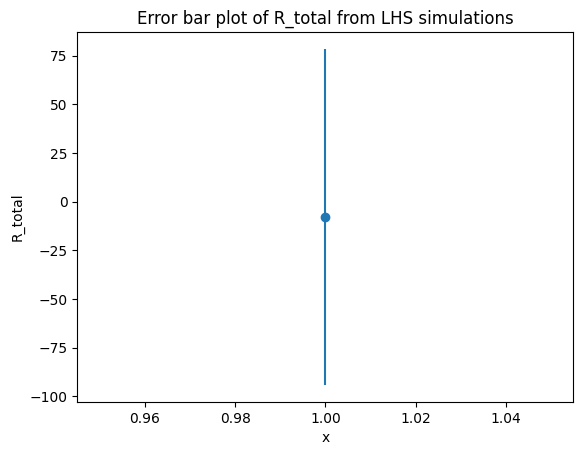

In [24]:
yavg = np.mean(Output, axis=0)
yerr = np.std(Output, axis=0)

plt.errorbar(x, yavg, yerr, fmt='o')
plt.xlabel('x')
plt.ylabel(labelstring)
plt.title('Error bar plot of ' + labelstring + ' from LHS simulations')
plt.show()

### Compute partial rank correlation coefficients to compare simulation outputs with parameters

In [25]:
SampleResult = []

# For R_total you used x = np.array([1.0]) so there is only ONE index: 0
x_idx = 0
x_idx2 = x_idx + 1

LHS = [*zip(*LHSparams)]
LHSarray = np.array(LHS)
Outputarray = np.array(Output)

subOut = Outputarray[:, x_idx:x_idx2]

LHSout = np.hstack((LHSarray, subOut))
SampleResult = LHSout.tolist()

Ranks = []
for s in range(sampleCount):
    indices = list(range(len(SampleResult[s])))
    indices.sort(key=lambda k: SampleResult[s][k])
    r = [0] * len(indices)
    for i, k in enumerate(indices):
        r[k] = i
    Ranks.append(r)

C = np.corrcoef(Ranks)

if np.linalg.det(C) < 1e-16:
    Cinv = np.linalg.pinv(C)
else:
    Cinv = np.linalg.inv(C)

# Output column is the LAST column => index = parameterCount
resultIdx = parameterCount

prcc = np.zeros(parameterCount)
for w in range(parameterCount):
    prcc[w] = -Cinv[w, resultIdx] / np.sqrt(Cinv[w, w] * Cinv[resultIdx, resultIdx])

### Plot the PRCCs for each parameter

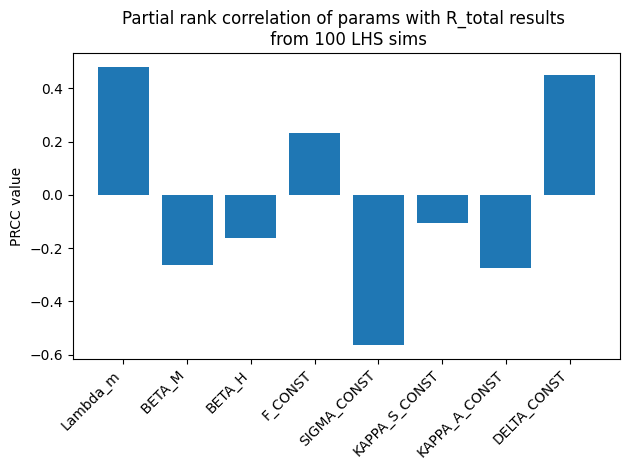

In [26]:
xp = np.arange(parameterCount)

plt.bar(xp, prcc, align='center')
plt.xticks(xp, list(parameters.keys()), rotation=45, ha='right')

plt.ylabel('PRCC value')

N = str(sampleCount)
plt.title(
    'Partial rank correlation of params with ' + labelstring +
    ' results \n from ' + N + ' LHS sims'
)

plt.tight_layout()
plt.show()

### Can also do PRCCs over time...

In [27]:
SampleResult = []

# For R_total: output column is the LAST column => index = parameterCount
resultIdx = parameterCount

# PRCC only for parameters => shape (parameterCount, len(x))
prcc = np.zeros((parameterCount, len(x)))

LHS = [*zip(*LHSparams)]
LHSarray = np.array(LHS)
Outputarray = np.array(Output)

for xi in range(len(x)):      # loop through x index
    xi2 = xi + 1

    subOut = Outputarray[:, xi:xi2]

    LHSout = np.hstack((LHSarray, subOut))
    SampleResult = LHSout.tolist()

    Ranks = []
    for s in range(sampleCount):
        indices = list(range(len(SampleResult[s])))
        indices.sort(key=lambda k: SampleResult[s][k])
        r = [0] * len(indices)
        for i, k in enumerate(indices):
            r[k] = i
        Ranks.append(r)

    C = np.corrcoef(Ranks)

    if np.linalg.det(C) < 1e-16:
        Cinv = np.linalg.pinv(C)
    else:
        Cinv = np.linalg.inv(C)

    for w in range(parameterCount):
        prcc[w, xi] = -Cinv[w, resultIdx] / np.sqrt(Cinv[w, w] * Cinv[resultIdx, resultIdx])

### Plot PRCC values as they vary over time or space.
#### *Notice PRCC can change with respect to the independent variable (x-axis). This may be helpful for certain applications, as opposed to only looking at a "snapshot."*

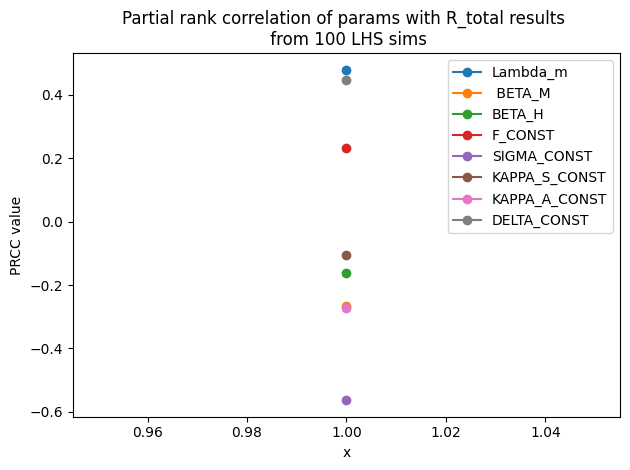

In [28]:
for p in range(parameterCount):
    plt.plot(x, prcc[p, :], marker='o')

labels = list(parameters.keys())
plt.legend(labels, loc='best')

plt.ylabel('PRCC value')
plt.xlabel('x')

N = str(sampleCount)
plt.title(
    'Partial rank correlation of params with ' + labelstring +
    ' results \n from ' + N + ' LHS sims'
)

plt.tight_layout()
plt.show()

##That's it, you're done! Happy modeling.